In [66]:
!pip install -q opencv-python-headless

import os
import re
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
import matplotlib.pyplot as plt

from PIL import Image, ImageFilter, ImageOps
from dataclasses import dataclass
from google.colab import files

In [67]:
class Config:
    IMG_HEIGHT    = 64
    MAX_IMG_WIDTH = 1280
    IMG_CHANNELS  = 1
    PAD_VALUE     = 255
    ALPHABET      = " !\"#&'()*+,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
    BLANK_IDX     = 0
    NUM_CLASSES   = len(ALPHABET) + 1

class Tokenizer:
    def __init__(self):
        self.blank_idx = Config.BLANK_IDX
        self.char2idx  = {c: i + 1 for i, c in enumerate(Config.ALPHABET)}
        self.idx2char  = {i + 1: c for i, c in enumerate(Config.ALPHABET)}
        self.idx2char[0] = ""

@dataclass
class ModelConfig:
    img_height: int = 64
    img_channels: int = 1
    max_img_width: int = 1280
    num_classes: int = 81
    lstm_hidden: int = 384
    lstm_layers: int = 3
    lstm_dropout: float = 0.4
    head_dropout: float = 0.2

In [68]:
class ResNetBackbone(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        resnet = models.resnet34(weights=None)

        old_w = resnet.conv1.weight.data.mean(dim=1, keepdim=True)
        resnet.conv1 = nn.Conv2d(
            cfg.img_channels, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        resnet.conv1.weight.data = old_w

        for block in resnet.layer4:
            for _, m in block.named_modules():
                if isinstance(m, nn.Conv2d) and m.stride == (2, 2):
                    m.stride = (1, 1)
            if block.downsample:
                for m in block.downsample.modules():
                    if isinstance(m, nn.Conv2d) and m.stride == (2, 2):
                        m.stride = (1, 1)

        self.features = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3, resnet.layer4
        )

    def forward(self, x):
        return self.features(x)

In [69]:
class HTRModel(nn.Module):
    def __init__(self, cfg=ModelConfig()):
        super().__init__()
        self.cfg = cfg
        self.cnn = ResNetBackbone(cfg)

        with torch.no_grad():
            dummy = torch.zeros(1, cfg.img_channels, cfg.img_height, cfg.max_img_width)
            _, C, H, W = self.cnn(dummy).shape
            self.feature_size = C * H

        self.lstm = nn.LSTM(
            input_size=self.feature_size,
            hidden_size=cfg.lstm_hidden,
            num_layers=cfg.lstm_layers,
            bidirectional=True,
            batch_first=False,
            dropout=cfg.lstm_dropout if cfg.lstm_layers > 1 else 0.0
        )

        self.head = nn.Sequential(
            nn.Dropout(cfg.head_dropout),
            nn.Linear(cfg.lstm_hidden * 2, cfg.num_classes)
        )

    def forward(self, x):
        feat = self.cnn(x)                     # [B, C, H, W]
        B, C, H, W = feat.shape
        feat = feat.view(B, C * H, W).permute(2, 0, 1)  # [W, B, C*H]
        feat, _ = self.lstm(feat)
        return torch.log_softmax(self.head(feat), dim=-1)

In [70]:
#decode
def ctc_decode(logits, tok):
    preds = logits.argmax(-1)   # [T, B]
    T_, B = preds.shape
    out = []

    for b in range(B):
        prev = None
        txt = ""
        for t in range(T_):
            c = preds[t, b].item()
            if c != tok.blank_idx and c != prev:
                txt += tok.idx2char.get(c, "")
            prev = c
        out.append(txt)

    return out

@torch.no_grad()
def decode_with_confidence(logits, tok):
    log_probs = torch.log_softmax(logits, dim=-1)   # [T, B, C]
    preds = log_probs.argmax(-1)                    # [T, B]

    T_, B = preds.shape
    texts = []
    confs = []

    for b in range(B):
        prev = None
        txt = ""
        chosen_scores = []

        for t in range(T_):
            c = preds[t, b].item()
            score = log_probs[t, b, c].item()

            if c != tok.blank_idx and c != prev:
                txt += tok.idx2char.get(c, "")
                chosen_scores.append(score)

            prev = c

        texts.append(txt)
        confs.append(float(np.mean(chosen_scores)) if chosen_scores else -1e9)

    return texts, confs


In [71]:
#load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tok = Tokenizer()

model_cfg = ModelConfig(num_classes=Config.NUM_CLASSES)
model = HTRModel(model_cfg).to(device)

ckpt_path = "/content/htr_epoch043_best.pt"
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.eval()

print("Loaded epoch:", ckpt["epoch"])
print("Best CER    :", ckpt["best_cer"])


Loaded epoch: 43
Best CER    : 0.10376954889005087


In [72]:
#pre process
BASE_TRANSFORM = T.Compose([
    T.ToTensor(),
    T.Normalize([0.5], [0.5])
])


In [74]:
def resize_line(img):
    w, h = img.size
    new_h = Config.IMG_HEIGHT
    new_w = max(1, int(w * new_h / h))

    img = img.resize((new_w, new_h), Image.BILINEAR)

    if new_w >= Config.MAX_IMG_WIDTH:
        return img.crop((0, 0, Config.MAX_IMG_WIDTH, new_h))

    canvas = Image.new("L", (Config.MAX_IMG_WIDTH, new_h), Config.PAD_VALUE)
    canvas.paste(img, (0, 0))
    return canvas

In [75]:
def tight_crop_line(pil_img, margin=2):
    arr = np.array(pil_img.convert("L"))
    inv = 255 - arr
    col_sum = inv.sum(axis=0)

    if col_sum.max() <= 0:
        return pil_img

    cols = np.where(col_sum > 0.02 * col_sum.max())[0]
    if len(cols) == 0:
        return pil_img

    x1 = max(0, int(cols[0]) - margin)
    x2 = min(arr.shape[1], int(cols[-1]) + margin + 1)
    return pil_img.crop((x1, 0, x2, arr.shape[0]))

In [76]:
def clean_prediction(txt):
    txt = txt.replace("|", "I")
    txt = re.sub(r"\s+", " ", txt).strip()
    txt = re.sub(r"\s+([.,!?;:])", r"\1", txt)
    return txt

In [77]:
def score_text(txt, conf):
    txt = clean_prediction(txt)

    if not txt:
        return -1e9

    letters = sum(ch.isalpha() for ch in txt)
    spaces = txt.count(" ")
    weird = sum(not (ch.isalnum() or ch in " .,!?;:'\"-()") for ch in txt)

    score = conf
    score += 0.02 * letters
    score += 0.01 * spaces
    score -= 0.08 * weird

    if len(txt) > 3:
        upper_ratio = sum(ch.isupper() for ch in txt if ch.isalpha()) / max(1, letters)
        if 0.15 < upper_ratio < 0.95:
            score -= 0.10

    short_words = sum(1 for w in txt.split() if len(w) == 1)
    score -= 0.03 * short_words

    return score

In [79]:
def make_variants(pil_img):
    img = pil_img.convert("L")
    img = tight_crop_line(img)

    variants = []

    variants.append(("orig", img))
    variants.append(("autocontrast", ImageOps.autocontrast(img)))
    variants.append(("invert", ImageOps.invert(img)))
    variants.append(("autocontrast_invert", ImageOps.invert(ImageOps.autocontrast(img))))
    variants.append(("sharpen", img.filter(ImageFilter.SHARPEN)))
    variants.append(("sharp2", img.filter(ImageFilter.SHARPEN).filter(ImageFilter.SHARPEN)))

    arr = np.array(img)

    _, bw = cv2.threshold(arr, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    variants.append(("otsu", Image.fromarray(bw)))
    variants.append(("otsu_invert", Image.fromarray(255 - bw)))

    adp = cv2.adaptiveThreshold(
        arr, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 31, 11
    )
    variants.append(("adaptive", Image.fromarray(adp)))
    variants.append(("adaptive_invert", Image.fromarray(255 - adp)))

    uniq = []
    seen = set()
    for name, im in variants:
        key = np.array(im).tobytes()
        if key not in seen:
            seen.add(key)
            uniq.append((name, im))

    return uniq


In [80]:
@torch.no_grad()
def predict_line_best(pil_img, show_variants=False):
    candidates = []

    for name, var_img in make_variants(pil_img):
        prep = resize_line(var_img)
        t = BASE_TRANSFORM(prep).unsqueeze(0).to(device)

        logits = model(t)
        texts, confs = decode_with_confidence(logits, tok)

        raw_txt = texts[0]
        conf = confs[0]
        txt = clean_prediction(raw_txt)
        final_score = score_text(txt, conf)

        candidates.append({
            "variant": name,
            "text": txt,
            "conf": conf,
            "score": final_score,
            "image": var_img
        })

    candidates = sorted(candidates, key=lambda x: x["score"], reverse=True)

    if show_variants:
        print("Top variants:")
        for c in candidates[:5]:
            print(
                f'{c["variant"]:18s} | score={c["score"]:.4f} | '
                f'conf={c["conf"]:.4f} | text={c["text"]}'
            )

    return candidates[0], candidates

In [81]:
#line segmentation
def segment_lines(img_path, pad=4):
    bgr = cv2.imread(img_path)
    if bgr is None:
        raise FileNotFoundError(img_path)

    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(2.0, (8, 8))
    gray = clahe.apply(gray)

    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    k = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 1))
    bw = cv2.morphologyEx(bw, cv2.MORPH_OPEN, k)

    proj = bw.sum(axis=1)
    thr = proj.max() * 0.05
    rows = proj > thr

    regions = []
    in_line = False
    start = 0

    for i, r in enumerate(rows):
        if r and not in_line:
            in_line = True
            start = i
        elif not r and in_line:
            in_line = False
            if i - start > 8:
                regions.append((max(0, start - pad), min(bgr.shape[0], i + pad)))

    if in_line and bgr.shape[0] - start > 8:
        regions.append((max(0, start - pad), bgr.shape[0]))

    pil = Image.fromarray(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    lines = [pil.crop((0, y1, pil.width, y2)) for y1, y2 in regions]

    return lines, bgr, regions

In [82]:
#page recog
def recognize_page(img_path, show=True, show_variants=False):
    lines, dbg, regions = segment_lines(img_path)
    print(f"{len(lines)} LINE")

    if not lines:
        print("THERE IS NO LINE")
        return ""

    if show:
        dbg2 = dbg.copy()
        for i, (y1, y2) in enumerate(regions):
            cv2.rectangle(dbg2, (0, y1), (dbg.shape[1], y2), (0, 200, 0), 2)
            cv2.putText(
                dbg2, str(i + 1), (8, y1 + 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 220), 2
            )

        plt.figure(figsize=(14, 8))
        plt.imshow(cv2.cvtColor(dbg2, cv2.COLOR_BGR2RGB))
        plt.title(f"DETECTED LINES: {len(regions)}")
        plt.axis("off")
        plt.show()

    results = []

    for i, line in enumerate(lines):
        best, all_cands = predict_line_best(line, show_variants=show_variants)
        txt = best["text"]
        results.append(txt)

        if show:
            plt.figure(figsize=(14, 1.4))
            plt.imshow(np.array(line), cmap="gray")
            plt.title(
                f'LINE {i+1} [{best["variant"]}] score={best["score"]:.3f}: "{txt}"',
                fontsize=10, loc="left"
            )
            plt.axis("off")
            plt.tight_layout()
            plt.show()

    full = "\n".join(results)

    print("\n" + "=" * 50)
    print("RESULT:")
    print("=" * 50)
    print(full)

    return full

Saving WhatsApp Image 2026-03-15 at 01.44.25.jpeg to WhatsApp Image 2026-03-15 at 01.44.25 (1).jpeg
6 LINE


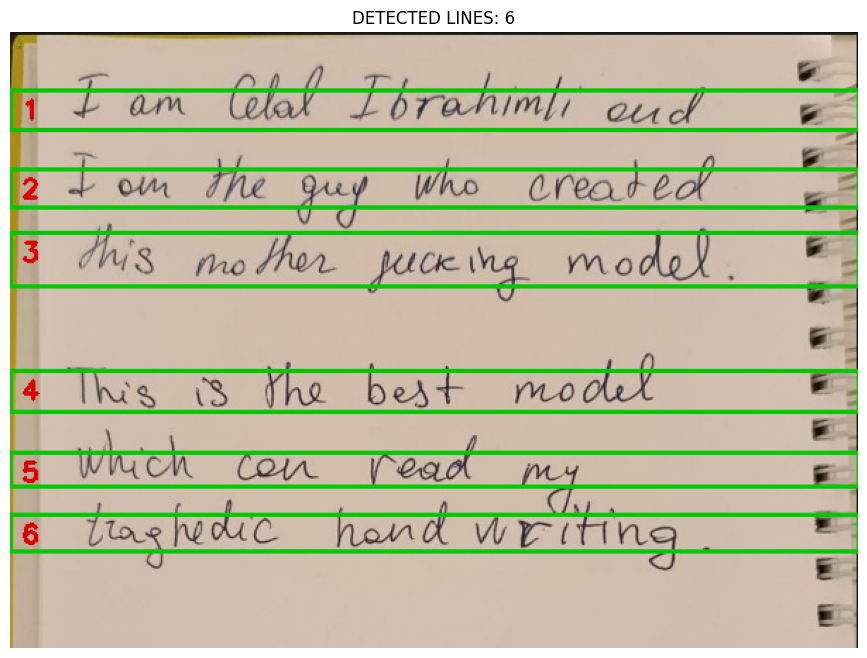

Top variants:
autocontrast       | score=0.2877 | conf=-0.1223 | text=i I am Lelal Ibrahimli and
sharp2             | score=0.2817 | conf=-0.2083 | text=ill I am Celal It brahimli " and e
sharpen            | score=0.2457 | conf=-0.1943 | text=iiI am Celal I brahimli " and
orig               | score=0.1767 | conf=-0.1833 | text=Di I am Lelal Ibrahimli and
adaptive           | score=0.1019 | conf=-0.4781 | text=lif It arn Lelal Ibratimli nd ae e


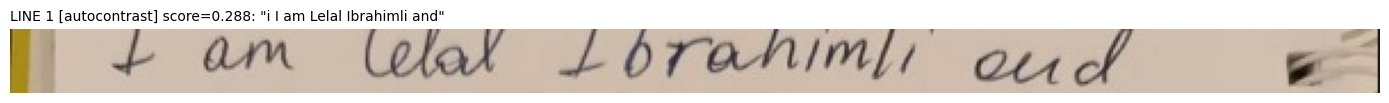

Top variants:
orig               | score=0.0280 | conf=-0.4520 | text=it on the gug who creat ote
otsu               | score=-0.0069 | conf=-0.4669 | text=I it an the gug who crat ote
adaptive           | score=-0.0131 | conf=-0.4731 | text=I it an the gug who crat ote
sharpen            | score=-0.0454 | conf=-0.5054 | text=it on the gug who creat ot e
sharp2             | score=-0.0482 | conf=-0.5582 | text=e at omn the qug who cret oe es


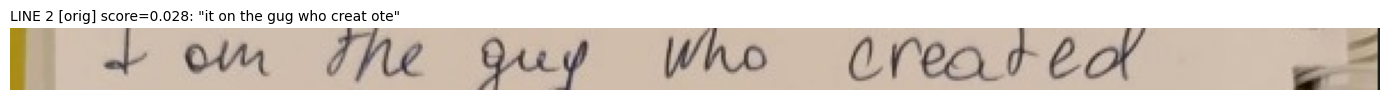

Top variants:
otsu               | score=0.3896 | conf=-0.2004 | text=of this mother qucking model. SF.I
adaptive           | score=0.3413 | conf=-0.1587 | text=o this mothen qucking model. I)
sharp2             | score=0.3310 | conf=-0.0490 | text=i this mothien peecking modiel. ##
autocontrast       | score=0.3123 | conf=-0.1877 | text=this mother pucking model. I7
orig               | score=0.2923 | conf=-0.1877 | text=this mother ucking model. I7


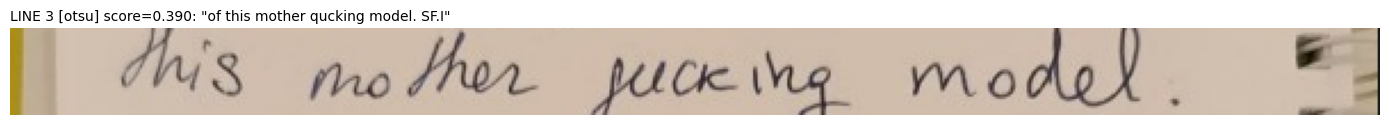

Top variants:
sharpen            | score=0.1374 | conf=-0.2626 | text=This is the best model e e
autocontrast       | score=0.1335 | conf=-0.2665 | text=This is the bett model e s
orig               | score=0.1156 | conf=-0.2844 | text=This is the bett model e s
otsu               | score=0.0928 | conf=-0.3072 | text=This is the bett modet. e s
adaptive           | score=0.0731 | conf=-0.3269 | text=This is the bett modet e s


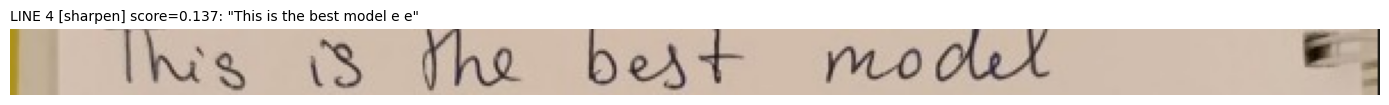

Top variants:
sharpen            | score=0.1637 | conf=-0.1663 | text=f Which con iread my
adaptive           | score=0.1627 | conf=-0.1873 | text=" TThrich con read thy
otsu               | score=0.1573 | conf=-0.1927 | text=which con read they
autocontrast       | score=0.1327 | conf=-0.1773 | text=Which con read my
sharp2             | score=0.1214 | conf=-0.2786 | text=of whicn can irecd mey.


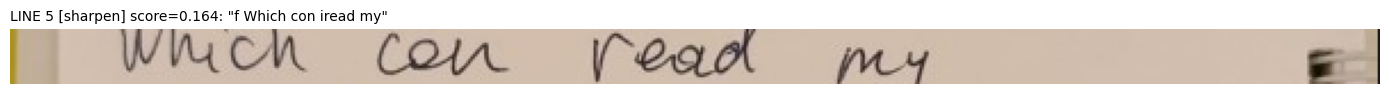

Top variants:
autocontrast       | score=0.2004 | conf=-0.2696 | text=ttaghedic hand Nritine as
orig               | score=0.1981 | conf=-0.2719 | text=ttaghedic hand Nritine as
sharpen            | score=0.1632 | conf=-0.3068 | text=y ttaghedic hand Nritine as
sharp2             | score=0.1139 | conf=-0.3861 | text=oy Ttaghedic hand i-ritin as
otsu               | score=0.0606 | conf=-0.3694 | text=taghedic hond writin as


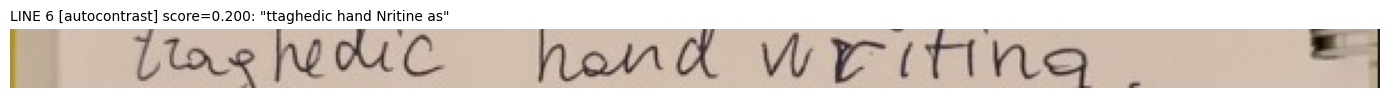


RESULT:
i I am Lelal Ibrahimli and
it on the gug who creat ote
of this mother qucking model. SF.I
This is the best model e e
f Which con iread my
ttaghedic hand Nritine as


In [83]:
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

text = recognize_page(img_path, show=True, show_variants=True)

In [105]:
!pip install -q transformers accelerate sentencepiece opencv-python-headless pillow

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageFilter
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from google.colab import files

In [106]:
# 1) LOAD HUGGING FACE HANDWRITTEN OCR MODEL
# =========================================================
MODEL_NAME = "microsoft/trocr-base-handwritten"
# MODEL_NAME = "microsoft/trocr-large-handwritten"

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = TrOCRProcessor.from_pretrained(MODEL_NAME)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

print("Loaded:", MODEL_NAME, "| device:", device)

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded: microsoft/trocr-base-handwritten | device: cuda


In [107]:
# 2) PAGE -> LINE SEGMENTATION
# =========================================================
def segment_lines(img_path, pad=4):
    bgr = cv2.imread(img_path)
    if bgr is None:
        raise FileNotFoundError(img_path)

    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    _, bw = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    k = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 1))
    bw = cv2.morphologyEx(bw, cv2.MORPH_OPEN, k)

    proj = bw.sum(axis=1)
    thr = proj.max() * 0.05
    rows = proj > thr

    regions = []
    in_line = False
    start = 0

    for i, r in enumerate(rows):
        if r and not in_line:
            in_line = True
            start = i
        elif not r and in_line:
            in_line = False
            if i - start > 8:
                regions.append((max(0, start - pad), min(bgr.shape[0], i + pad)))

    if in_line and bgr.shape[0] - start > 8:
        regions.append((max(0, start - pad), bgr.shape[0]))

    pil = Image.fromarray(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    lines = [pil.crop((0, y1, pil.width, y2)) for y1, y2 in regions]

    return lines, bgr, regions


In [109]:
# 3) TIGHT LINE CROP
# =========================================================
def tight_crop_line(pil_img, margin=3):
    arr = np.array(pil_img.convert("L"))
    ink = 255 - arr
    col_sum = ink.sum(axis=0)

    if col_sum.max() <= 0:
        return pil_img

    cols = np.where(col_sum > 0.02 * col_sum.max())[0]
    if len(cols) == 0:
        return pil_img

    x1 = max(0, int(cols[0]) - margin)
    x2 = min(arr.shape[1], int(cols[-1]) + margin + 1)

    return pil_img.crop((x1, 0, x2, arr.shape[0]))

In [111]:
# 4) MULTIPLE PREPROCESS VARIANTS
# =========================================================
def make_line_variants(pil_img):
    img = tight_crop_line(pil_img).convert("RGB")
    gray = ImageOps.grayscale(img)

    variants = [
        ("orig", img),
        ("autocontrast", ImageOps.autocontrast(img)),
        ("gray", gray.convert("RGB")),
        ("gray_autocontrast", ImageOps.autocontrast(gray).convert("RGB")),
        ("sharpen", img.filter(ImageFilter.SHARPEN)),
    ]

    return variants

In [113]:
# 5) SINGLE-LINE OCR WITH BEST VARIANT SELECTION
# =========================================================
@torch.no_grad()
def predict_line_trocr_best(pil_img, max_new_tokens=128, show_variants=False):
    candidates = []

    for name, var_img in make_line_variants(pil_img):
        pixel_values = processor(images=var_img, return_tensors="pt").pixel_values.to(device)

        generated_ids = model.generate(
            pixel_values,
            max_new_tokens=max_new_tokens,
            num_beams=6,
            early_stopping=True,
            no_repeat_ngram_size=2
        )

        text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

        score = len([c for c in text if c.isalnum() or c in " .,!?;:'\"-()"])
        candidates.append((score, name, text))

    candidates.sort(reverse=True)

    if show_variants:
        print("Top variants:")
        for score, name, text in candidates:
            print(f"{name:18s} | score={score:3d} | {text}")

    best_score, best_name, best_text = candidates[0]
    return best_text, best_name, candidates


In [114]:
# 6) FULL PAGE OCR
# =========================================================
def recognize_page_trocr(img_path, show=True, show_variants=False):
    lines, dbg, regions = segment_lines(img_path)
    print(f"{len(lines)} line detected")

    if not lines:
        print("No line found")
        return ""

    if show:
        dbg2 = dbg.copy()
        for i, (y1, y2) in enumerate(regions):
            cv2.rectangle(dbg2, (0, y1), (dbg.shape[1], y2), (0, 200, 0), 2)
            cv2.putText(
                dbg2,
                str(i + 1),
                (8, y1 + 20),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 0, 220),
                2
            )

        plt.figure(figsize=(14, 8))
        plt.imshow(cv2.cvtColor(dbg2, cv2.COLOR_BGR2RGB))
        plt.title(f"Detected lines: {len(regions)}")
        plt.axis("off")
        plt.show()

    results = []

    for i, line in enumerate(lines):
        txt, variant_name, candidates = predict_line_trocr_best(
            line,
            show_variants=show_variants
        )
        results.append(txt)

        if show:
            plt.figure(figsize=(14, 1.5))
            plt.imshow(np.array(line))
            plt.title(f'Line {i+1} [{variant_name}]: "{txt}"', fontsize=10, loc="left")
            plt.axis("off")
            plt.tight_layout()
            plt.show()

    full = "\n".join(results)

    print("\n" + "=" * 50)
    print("RESULT:")
    print("=" * 50)
    print(full)

    return full


Saving Ekran şəkli 2026-03-15 021529.png to Ekran şəkli 2026-03-15 021529 (1).png
18 line detected


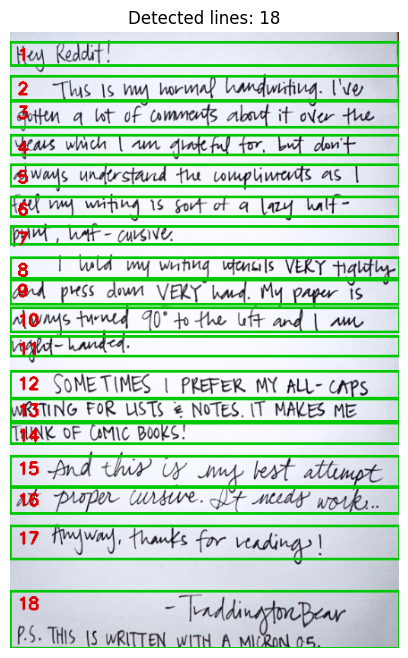

Top variants:
sharpen            | score= 23 | they Reddit ! 2000 2001
orig               | score= 22 | Hey Reddit ! 2000 2001
gray_autocontrast  | score= 22 | Hey Reddit ! 2000 2001
gray               | score= 22 | Hey Reddit ! 2000 2001
autocontrast       | score= 22 | Hey Reddit ! 2000 2001


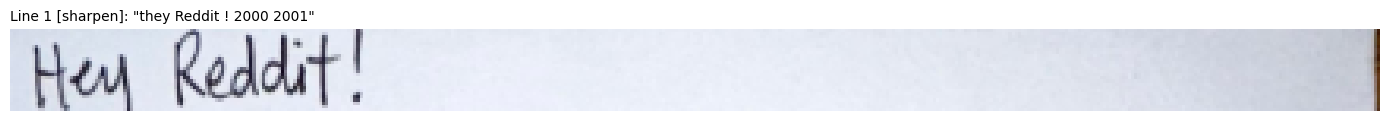

Top variants:
orig               | score= 42 | # This is my normal handwriting . I've ever
autocontrast       | score= 42 | # This is my normal handwriting . I've ever
sharpen            | score= 38 | 2 This is my normal handwriting . I've
gray_autocontrast  | score= 37 | # This is my normal handwriting . I've
gray               | score= 37 | # This is my normal handwriting . I've


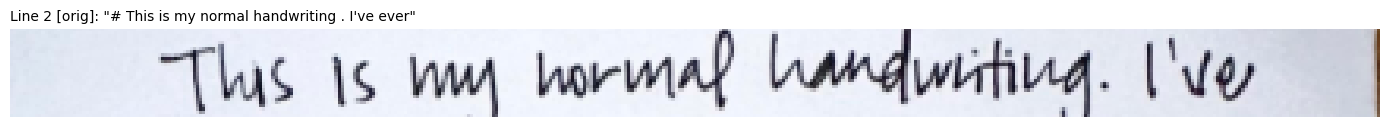

Top variants:
autocontrast       | score= 44 | gotten a lot of comments about it over the I
sharpen            | score= 42 | gotten a lot of comments about it over the
orig               | score= 42 | gotten a lot of comments about it over the
gray_autocontrast  | score= 42 | gotten a lot of comments about it over the
gray               | score= 42 | gotten a lot of comments about it over the


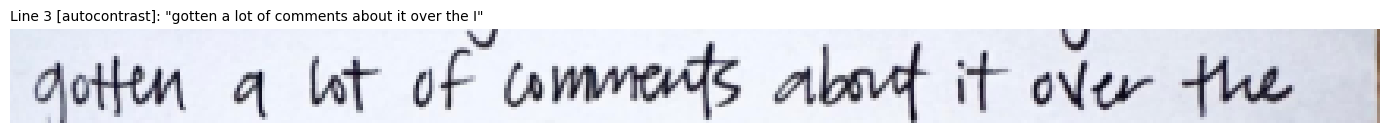

Top variants:
sharpen            | score= 41 | years which I am grateful for , but don't
orig               | score= 41 | years which I am grateful for , but don't
gray_autocontrast  | score= 41 | years which I am grateful for , but don't
gray               | score= 41 | years which I am grateful for , but don't
autocontrast       | score= 41 | years which I am grateful for , but don't


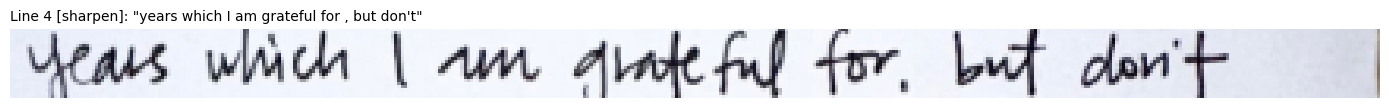

Top variants:
sharpen            | score= 38 | always understand the compliments as I
orig               | score= 38 | always understand the compliments as I
gray_autocontrast  | score= 38 | always understand the compliments as I
gray               | score= 38 | always understand the compliments as I
autocontrast       | score= 38 | always understand the compliments as I


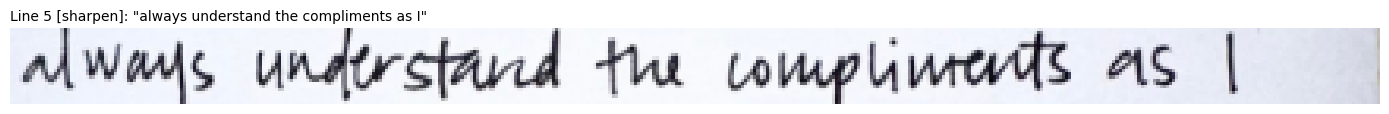

Top variants:
sharpen            | score= 40 | feel my writing is sort of a lazy half -
orig               | score= 40 | feel my writing is sort of a lazy half -
gray_autocontrast  | score= 40 | feel my writing is sort of a lazy half -
gray               | score= 40 | feel my writing is sort of a lazy half -
autocontrast       | score= 40 | feel my writing is sort of a lazy half -


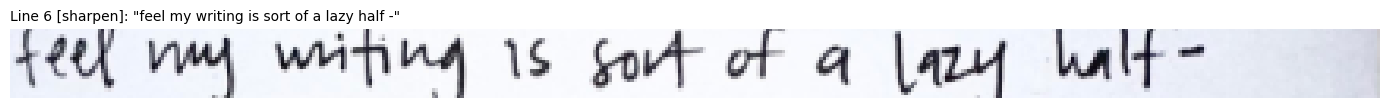

Top variants:
orig               | score= 35 | print , heat-cussive , 2000 2001 02
gray_autocontrast  | score= 35 | print , heat-cussive , 2000 2001 02
gray               | score= 35 | print , heat-cussive , 2000 2001 02
autocontrast       | score= 35 | print , heat-cussive , 2000 2001 02
sharpen            | score= 34 | print , hat-cussive , 2000 2001 02


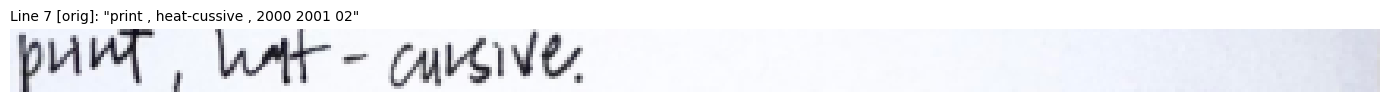

Top variants:
sharpen            | score= 40 | # I hold my writing utencils VERY tightly
orig               | score= 40 | # I hold my writing utonails VERY that by
gray_autocontrast  | score= 40 | # I hold my writing utonails VERY that he
gray               | score= 40 | # I hold my writing utonails VERY that by
autocontrast       | score= 40 | # I hold my writing utonails VERY that by


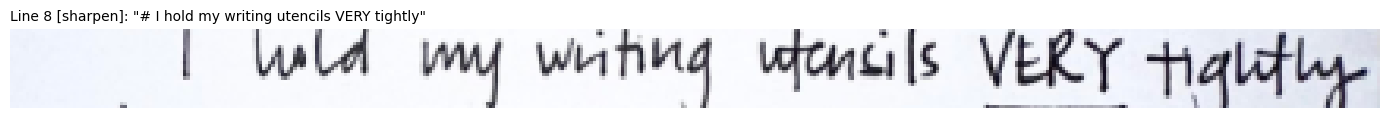

Top variants:
sharpen            | score= 40 | and press down VERRY " and my paper is "
orig               | score= 40 | and press down VERRY " and my paper is "
autocontrast       | score= 40 | and press down VERRY " and my paper is "
gray_autocontrast  | score= 39 | and press down VERY " and my paper is "
gray               | score= 39 | and press down VERY " and my paper is "


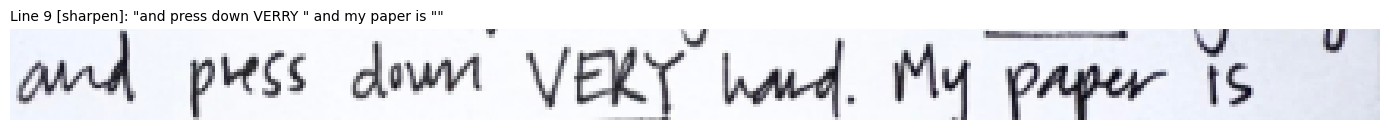

Top variants:
sharpen            | score= 38 | always turned 90" to the left and I am
orig               | score= 38 | always turned 90" to the left and I am
gray_autocontrast  | score= 38 | always turned 90" to the left and I am
gray               | score= 38 | always turned 90" to the left and I am
autocontrast       | score= 38 | always turned 90" to the left and I am


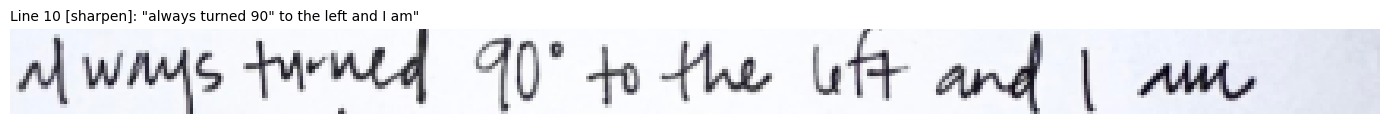

Top variants:
sharpen            | score= 25 | rigled-handed . 1,0005000
orig               | score= 17 | rigled-handed . 3/
gray_autocontrast  | score= 17 | rigled-handed . 1/
gray               | score= 17 | rigled-handed . 1/
autocontrast       | score= 17 | rigled-handed . 1/


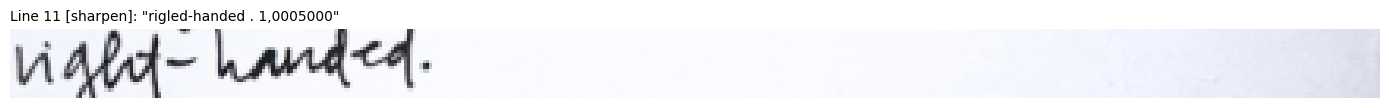

Top variants:
sharpen            | score= 34 | # some times I prefer my all-caps .
orig               | score= 34 | # some times I prefer my all-caps .
gray_autocontrast  | score= 34 | # some times I prefer my all-caps .
gray               | score= 34 | # some times I prefer my all-caps .
autocontrast       | score= 34 | # some times I prefer my all-caps .


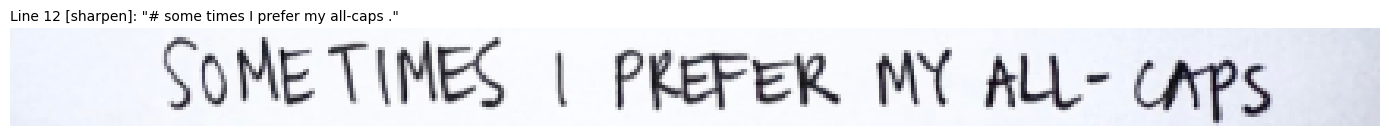

Top variants:
sharpen            | score= 38 | writing for lists # notes . it makes me
orig               | score= 38 | writing for lists # notes . it makes me
gray_autocontrast  | score= 38 | writing for lists # notes . it makes me
gray               | score= 38 | writing for lists # notes . it makes me
autocontrast       | score= 38 | writing for lists # notes . it makes me


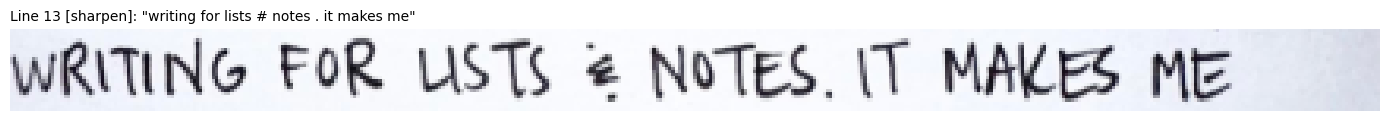

Top variants:
sharpen            | score= 32 | Think of Comic Books ! 2000 2001
orig               | score= 32 | Think of comic books ! 2000 2001
gray_autocontrast  | score= 32 | Think of comic books ! 2000 2001
gray               | score= 32 | Think of comic books ! 2000 2001
autocontrast       | score= 32 | Think of comic books ! 2000 2001


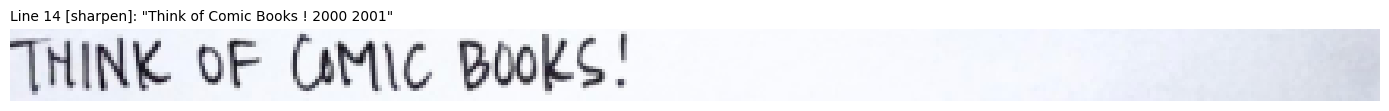

Top variants:
sharpen            | score= 29 | . And this is my best attempt
orig               | score= 29 | " And this is my best attempt
gray               | score= 29 | " And this is my best attempt
gray_autocontrast  | score= 28 | # And this is my best attempt
autocontrast       | score= 28 | # And this is my best attempt


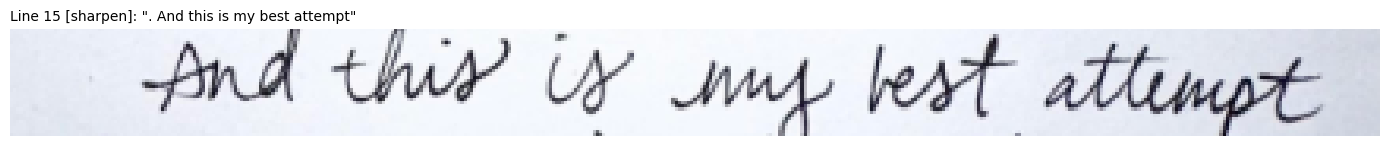

Top variants:
sharpen            | score= 39 | at proper cursive . It needs work ... .
orig               | score= 38 | at proper cursive . It needs works ...
gray_autocontrast  | score= 38 | at proper cursive . It needs works ...
gray               | score= 38 | at proper cursive . It needs works ...
autocontrast       | score= 38 | at proper cursive . It needs works ...


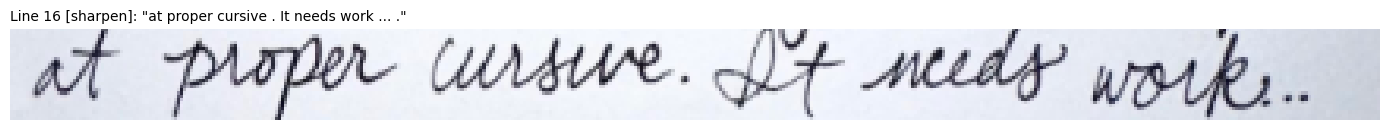

Top variants:
sharpen            | score= 34 | off Anyway , thanks for readings ,
orig               | score= 34 | off Anyway , thanks for readings ,
gray_autocontrast  | score= 34 | off Anyway , thanks for readings ,
gray               | score= 34 | off Anyway , thanks for readings ,
autocontrast       | score= 34 | off Anyway , thanks for readings ,


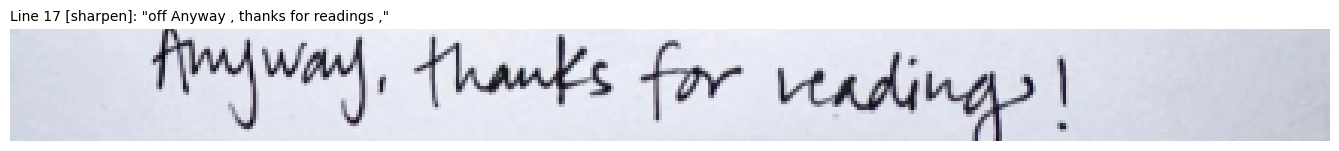

Top variants:
orig               | score= 41 | p.s. This is written with a dialogue bear
gray_autocontrast  | score= 41 | p.s. This is written with a dialogue bear
gray               | score= 41 | p.s. This is written with a dialogue bear
autocontrast       | score= 41 | p.s. This is written with a dialogue bear
sharpen            | score= 40 | P.S. This is written with a dingler bear


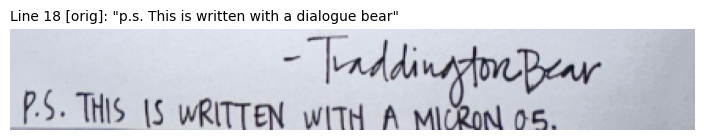


RESULT:
they Reddit ! 2000 2001
# This is my normal handwriting . I've ever
gotten a lot of comments about it over the I
years which I am grateful for , but don't
always understand the compliments as I
feel my writing is sort of a lazy half -
print , heat-cussive , 2000 2001 02
# I hold my writing utencils VERY tightly
and press down VERRY " and my paper is "
always turned 90" to the left and I am
rigled-handed . 1,0005000
# some times I prefer my all-caps .
writing for lists # notes . it makes me
Think of Comic Books ! 2000 2001
. And this is my best attempt
at proper cursive . It needs work ... .
off Anyway , thanks for readings ,
p.s. This is written with a dialogue bear


In [122]:
#UPLOAD IMAGE AND RUN
# =========================================================
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

text = recognize_page_trocr(img_path, show=True, show_variants=True)